## Setup

### Imports

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

### Config

In [2]:
NPZ_FILE_PATH = Path("./frame_dump.npz")

In [3]:
# Read chirp parameters from metadata or set manually
READ_CHIRP_CONFIG_FROM_METADATA = True
if not READ_CHIRP_CONFIG_FROM_METADATA:
    num_chirps_per_frame = 8
    num_tx_ant = 2
    num_rx_ant = 3
    num_adc_samples = 256
    num_chirp_loops = num_chirps_per_frame // num_tx_ant

BANDWIDTH = 2.7 * 10e9 


## Read data from file

### Extract config params from metadata

In [4]:
if READ_CHIRP_CONFIG_FROM_METADATA:
    if not NPZ_FILE_PATH.is_file():
        raise FileNotFoundError(f"The specified NPZ file was not found at: {NPZ_FILE_PATH}")
    try:
        loaded_data = np.load(NPZ_FILE_PATH, allow_pickle=True)
    except Exception as e:
        print(f"Error loading NPZ file: {e}")

    available_keys = list(loaded_data.keys())

    if 'config_metadata' in loaded_data:
        try:
            config_metadata = loaded_data['config_metadata'].item()
            if isinstance(config_metadata, dict):
                print("Successfully extracted 'config_metadata' dictionary")
            else:
                print(f"'config_metadata' key exists but is not a dictionary. Type: {type(config_metadata)}")
                config_metadata = None
        except Exception as e:
            print(f"Error extracting 'config_metadata': {e}")
    else:
        print("'config_metadata' key not found in the NPZ file.")
else:
    print("Skipping extraction of parameters. You must set them manually.")

Successfully extracted 'config_metadata' dictionary


In [5]:
if READ_CHIRP_CONFIG_FROM_METADATA:
    num_chirps_per_frame = None
    num_tx_ant = None
    num_rx_ant = None
    num_adc_samples = None
    num_chirp_loops = None

    num_chirps_per_frame = config_metadata.get("num_chirps_per_frame")
    num_tx_ant = config_metadata.get("num_tx_ant")
    num_rx_ant = config_metadata.get("num_rx_ant")
    num_adc_samples = config_metadata.get("num_adc_samples")
    num_chirp_loops = config_metadata.get("num_chirp_loops")

    print(f"Extracted Parameters:")
    print(f"  num_chirps_per_frame: {num_chirps_per_frame}")
    print(f"  num_tx_ant: {num_tx_ant}")
    print(f"  num_rx_ant: {num_rx_ant}")
    print(f"  num_adc_samples: {num_adc_samples}")
    print(f"  num_chirp_loops: {num_chirp_loops}")

    essential_params = [num_chirps_per_frame, num_tx_ant, num_rx_ant, num_adc_samples, num_chirp_loops]
    if None in essential_params:
        print("One or more configuration parameters were not found in the metadata dictionary.")
else:
    print("Skipping extraction of parameters. You must set them manually.")

Extracted Parameters:
  num_chirps_per_frame: 512
  num_tx_ant: 2
  num_rx_ant: 3
  num_adc_samples: 128
  num_chirp_loops: 256


### Read ADC data from input file

In [6]:
adc_data_frames = None

if 'adc_data' in loaded_data:
    adc_data_frames = loaded_data['adc_data']
    print(f"Successfully loaded 'adc_data'.")
    print(f"  Shape: {adc_data_frames.shape}") # Expected: (num_frames, num_chirp_loops, num_channels, num_adc_samples)
    print(f"  Data Type: {adc_data_frames.dtype}")
else:
    print("Error: 'adc_data' key not found in the NPZ file. Cannot load frame data.")


# Read other saved information
recorded_frame_count = None
target_frame_count = None

if 'num_frames_recorded_actual' in loaded_data:
    # Saved as np.array(int), so use .item() to get the scalar back
    recorded_frame_count = loaded_data['num_frames_recorded_actual'].item()
    print(f"  Actual number of frames recorded: {recorded_frame_count}")

if 'num_frames_target_config' in loaded_data:
    # Saved as np.array(int), so use .item() to get the scalar back
    target_frame_count = loaded_data['num_frames_target_config'].item()
    print(f"  Target number of frames configured: {target_frame_count}")


Successfully loaded 'adc_data'.
  Shape: (100, 256, 6, 128)
  Data Type: float32

--- Reading Other Saved Information ---
Actual number of frames recorded: 100
Target number of frames configured: 100


## Plot the data

### Range Profile

Info: num_frames_loaded: 100, num_chirp_loops_loaded: 256, num_channels_loaded: 6, num_samples_loaded: 128
Selected data: Frame 4, Chirp Loop 0, Channel 3
  Extracted chirp data shape: (128,)


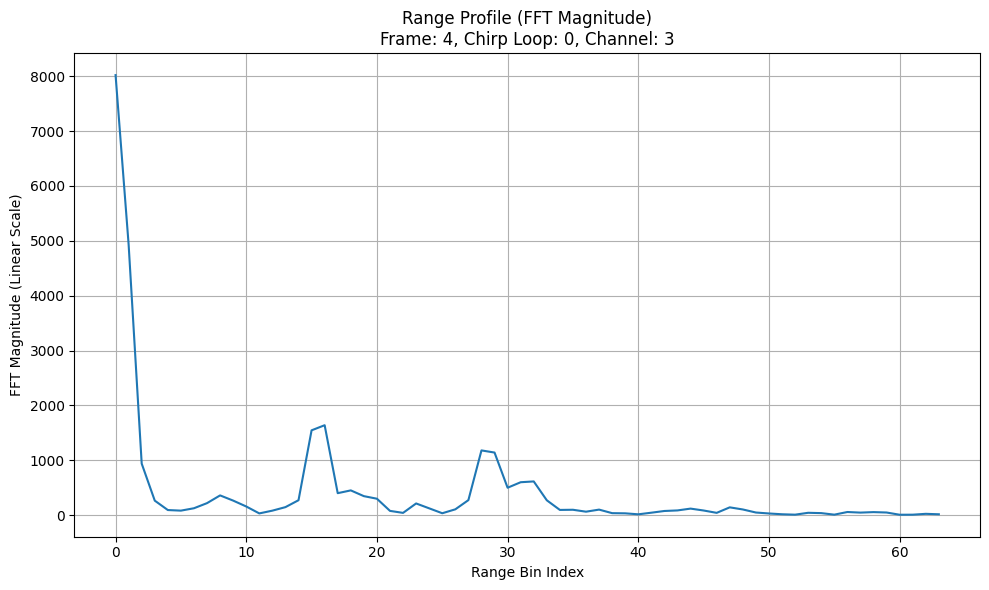

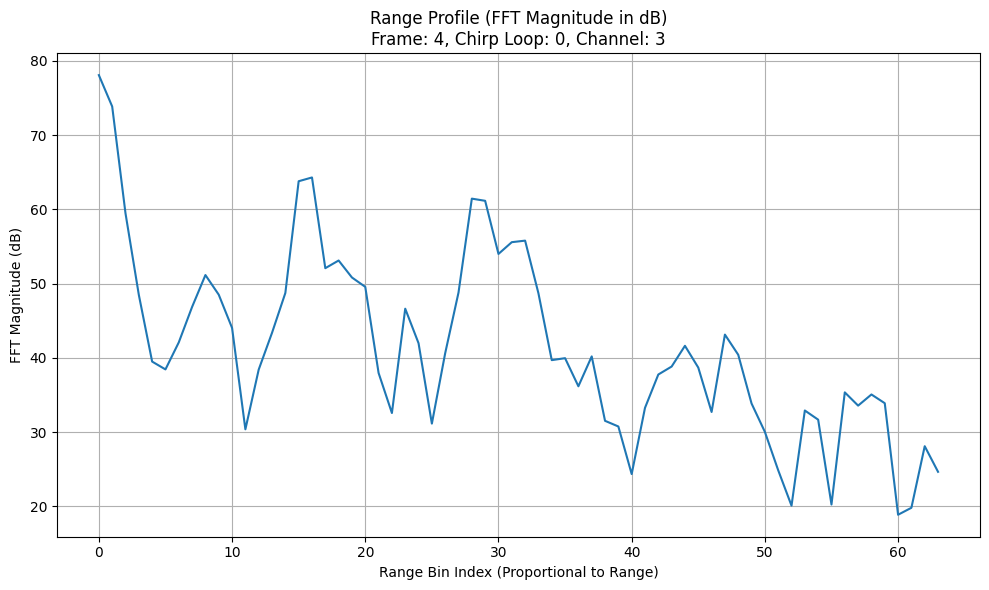

In [7]:

frame_index_to_plot = 4       # Index of the frame to use
chirp_loop_index_to_plot = 0  # Index of the chirp loop within the frame
channel_index_to_plot = 3     # Index of the virtual channel (0 to num_tx_ant * num_rx_ant - 1)

try:
    num_virtual_antennas = num_tx_ant * num_rx_ant

    num_frames_loaded = adc_data_frames.shape[0]
    num_chirp_loops_loaded = adc_data_frames.shape[1]
    num_channels_loaded = adc_data_frames.shape[2]
    num_samples_loaded = adc_data_frames.shape[3]
    print(f"Info: num_frames_loaded: {num_frames_loaded}, num_chirp_loops_loaded: {num_chirp_loops_loaded}, num_channels_loaded: {num_channels_loaded}, num_samples_loaded: {num_samples_loaded}")

    print(f"Selected data: Frame {frame_index_to_plot}, Chirp Loop {chirp_loop_index_to_plot}, Channel {channel_index_to_plot}")

    # Extract the chirp of interest from the frame
    selected_chirp = adc_data_frames[frame_index_to_plot, chirp_loop_index_to_plot, channel_index_to_plot, :]
    print(f"  Extracted chirp data shape: {selected_chirp.shape}")

    # Apply Blackman window
    window = np.blackman(num_adc_samples)
    chirp_windowed = selected_chirp * window

    # FFT along the fast time axis
    range_fft_complex = np.fft.fft(chirp_windowed, n=num_adc_samples)

    # Calculate Magnitude
    # Only first half of FFT is needed due to real-valued ADC input
    range_fft_magnitude = np.abs(range_fft_complex[:num_adc_samples // 2])

    # Plot linear scale range profile
    # Create an array representing FFT range bins
    range_bins = np.arange(num_adc_samples // 2)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(range_bins, range_fft_magnitude)

    ax.set_title(f'Range Profile (FFT Magnitude)\nFrame: {frame_index_to_plot}, Chirp Loop: {chirp_loop_index_to_plot}, Channel: {channel_index_to_plot}')
    ax.set_xlabel('Range Bin Index')
    ax.set_ylabel('FFT Magnitude (Linear Scale)')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot range profile in dB
    epsilon = 1e-10
    range_fft_db = 20 * np.log10(range_fft_magnitude + epsilon)

    fig_db, ax_db = plt.subplots(figsize=(10, 6))
    ax_db.plot(range_bins, range_fft_db)

    ax_db.set_title(f'Range Profile (FFT Magnitude in dB)\nFrame: {frame_index_to_plot}, Chirp Loop: {chirp_loop_index_to_plot}, Channel: {channel_index_to_plot}')
    ax_db.set_xlabel('Range Bin Index (Proportional to Range)')
    ax_db.set_ylabel('FFT Magnitude (dB)')
    ax_db.grid(True)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error during range profile calculation/plotting: {e}")

### Micro Doppler Plot

In [9]:
# TODO